# Preceptron en un conjunto de 100 datos

Para esta práctica necesita tener instalado SciLab, si no lo tiene 
1. instalelo desde `https://www.scilab.org/download`
2. En la carpeta `actividades-ia\codigos\scilab\basicos\` 
    * ejecute el programa `creaArchivoTrabajo.sce` este crea un conjunto de puntos en el plano y les asigna una clase de manera aleatoria, 
    * el programa produce como resultado un archivo: `datos_con_header.csv` con 20 puntos, 
3. Modifique el código anterior para que genere 100 puntos.
4. Si no puede ejecuta el archivo `creaArchivoTrabajo.sce`, trabaje con el archivo 'datos_con_header.csv' (con 20 datos) de esta carpeta.

## cargar bibliotecas

Para leer los datos csv necesitaremos la biblioteca panadas.

In [1]:
import pandas as pd

## cargamos los datos desde el archivo

In [8]:
# Leer un CSV simple
df = pd.read_csv("datos_con_header.csv")

# Ver las primeras filas
print(df.head(10))



   x_1  x_2  y
0   62  100 -1
1    5   92 -1
2   97   49  1
3   30    6  1
4   63    2  1
5   15   95 -1
6   27   48 -1
7   49   68 -1
8   83    1  1
9   55   84 -1


## Graficar los datos

In [13]:
import matplotlib
print(matplotlib.__version__) # revisamos si tenemos la libreria

3.11.2


Generamos la gráfica

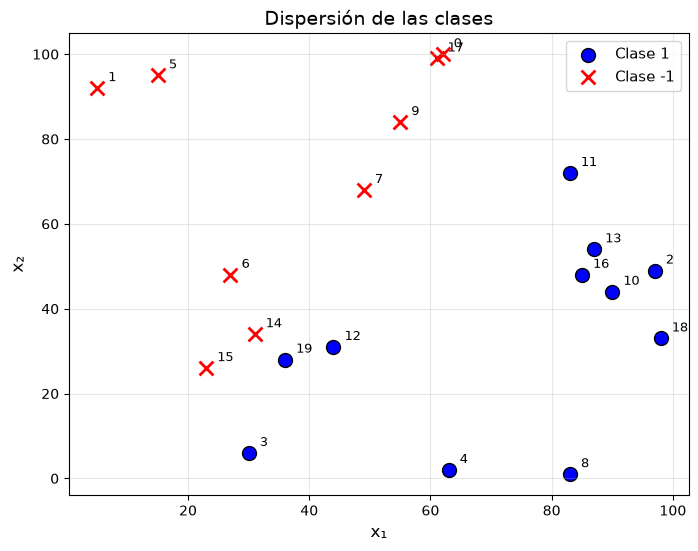

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el DataFrame con tus datos


# Separar por clase
clase_1  = df[df["y"] == 1]
clase_m1 = df[df["y"] == -1]

# Graficar
plt.figure(figsize=(8, 6))

plt.scatter(clase_1["x_1"], clase_1["x_2"],
            color="blue", marker="o", s=100,
            edgecolors="k", label="Clase 1")

plt.scatter(clase_m1["x_1"], clase_m1["x_2"],
            color="red", marker="x", s=100,
            linewidths=2, label="Clase -1")

# Etiquetas y estilo
plt.xlabel("x₁", fontsize=12)
plt.ylabel("x₂", fontsize=12)
plt.title("Dispersión de las clases", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Opcional: mostrar los índices de cada punto
for i, row in df.iterrows():
    plt.annotate(str(i), (row["x_1"], row["x_2"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

plt.show()

## preparar

Convertir dataframe a un arreglo.

In [ ]:
# Convertir el DataFrame a arreglo NumPy (incluye la columna y)
datos = df.to_numpy()
print(datos)
print(datos.shape)   # (10, 3)
print(datos.dtype)   # int64

[[ 62 100  -1]
 [  5  92  -1]
 [ 97  49   1]
 [ 30   6   1]
 [ 63   2   1]
 [ 15  95  -1]
 [ 27  48  -1]
 [ 49  68  -1]
 [ 83   1   1]
 [ 55  84  -1]
 [ 90  44   1]
 [ 83  72   1]
 [ 44  31   1]
 [ 87  54   1]
 [ 31  34  -1]
 [ 23  26  -1]
 [ 85  48   1]
 [ 61  99  -1]
 [ 98  33   1]
 [ 36  28   1]]
(20, 3)
int64


In [12]:
# ============================================
# PERCEPTRÓN SIMPLE - Sin librerías externas
# ============================================

# Datos: cada fila es [x1, x2, y]

# --- Hiperparámetros ---
eta = 0.001       # tasa de aprendizaje
epocas = 100      # número máximo de épocas

# --- Inicializar pesos y sesgo ---
w1 = 0.0
w2 = 0.0
b  = 0.0

# --- Función de activación (signo) ---
def predecir(x1, x2):
    suma = w1 * x1 + w2 * x2 + b
    return 1 if suma >= 0 else -1

# --- Entrenamiento ---
for epoca in range(epocas):
    errores = 0
    for x1, x2, y in datos:
        y_pred = predecir(x1, x2)
        error = y - y_pred
        if error != 0:
            w1 += eta * error * x1
            w2 += eta * error * x2
            b  += eta * error
            errores += 1
    print(f"Época {epoca+1:3d} | errores: {errores} | w1={w1:.4f} w2={w2:.4f} b={b:.4f}")
    if errores == 0:
        print(f"\n✅ Convergió en la época {epoca+1}")
        break

# --- Resultados finales ---
print("\n===== Parámetros finales =====")
print(f"w1 = {w1:.4f}")
print(f"w2 = {w2:.4f}")
print(f"b  = {b:.4f}")

# --- Evaluación ---
print("\n===== Predicciones =====")
print(f"{'x1':>5} {'x2':>5} {'y_real':>8} {'y_pred':>8} {'correcto':>10}")
print("-" * 45)
aciertos = 0
for x1, x2, y in datos:
    y_pred = predecir(x1, x2)
    ok = "✓" if y_pred == y else "✗"
    if y_pred == y:
        aciertos += 1
    print(f"{x1:>5} {x2:>5} {y:>8} {y_pred:>8} {ok:>10}")

print(f"\nPrecisión: {aciertos}/{len(datos)} = {100*aciertos/len(datos):.1f}%")

Época   1 | errores: 7 | w1=0.2020 w2=-0.2100 b=-0.0020
Época   2 | errores: 0 | w1=0.2020 w2=-0.2100 b=-0.0020

✅ Convergió en la época 2

===== Parámetros finales =====
w1 = 0.2020
w2 = -0.2100
b  = -0.0020

===== Predicciones =====
   x1    x2   y_real   y_pred   correcto
---------------------------------------------
   62   100       -1       -1          ✓
    5    92       -1       -1          ✓
   97    49        1        1          ✓
   30     6        1        1          ✓
   63     2        1        1          ✓
   15    95       -1       -1          ✓
   27    48       -1       -1          ✓
   49    68       -1       -1          ✓
   83     1        1        1          ✓
   55    84       -1       -1          ✓
   90    44        1        1          ✓
   83    72        1        1          ✓
   44    31        1        1          ✓
   87    54        1        1          ✓
   31    34       -1       -1          ✓
   23    26       -1       -1          ✓
   85    48        1  